# Análise do Impacto da Variação do Preço do Combustível no Preço dos Alimentos em Moçambique: Caso de Estudo do Milho Branco

Este projecto tem como objectivo analisar de que forma as variações nos preços dos combustíveis influenciam o preço do milho branco no mercado moçambicano, utilizando técnicas de Análise Exploratória de Dados (EDA) e testes de hipóteses estatísticas.

O estudo baseia-se em dados históricos, que passam por processos de limpeza, transformação e preparação, de modo a garantir maior qualidade e fiabilidade nas análises realizadas. Por fim, são apresentados os principais resultados, conclusões e recomendações obtidas ao longo do estudo.


## Objectivos Específicos
* Realizar a limpeza, transformação e preparação dos dados para melhorar a qualidade da análise.
* Explorar os conjuntos de dados através de técnicas de Análise Exploratória de Dados (EDA).
* Analisar o impacto da variação do preço dos combustíveis no preço do milho branco em Moçambique.
* Formular e testar hipóteses estatísticas relacionadas à influência dos combustíveis no preço do milho branco.
* Avaliar a significância estatística das relações identificadas nos dados.
* Produzir insights, conclusões e recomendações que possam apoiar análises futuras e auxiliar na compreensão do comportamento dos preços.

**Nota:** O conjunto de dados original contém informações sobre vários produtos alimentares. No entanto, para este estudo, foi seleccionado o milho branco como amostra de análise.

---

# I. Base

### Bibliotecas usadas

In [224]:
# Bibliotecas
import os
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, levene, ttest_ind

import warnings
warnings.filterwarnings('ignore')

### Funções principais

In [225]:
def analisar_qualidade(df, df_caminho):
    """
    Realiza uma análise básica da qualidade de um dataset,
    apresentando informações sobre dimensões, uso de memória,
    valores ausentes, duplicados, tipos de dados e estatísticas
    descritivas das colunas numéricas.
    """
    
    # Dimensões básicas
    total_linhas = df.shape[0]
    total_colunas = df.shape[1]
    total_celulas = total_linhas * total_colunas
    
    # Tamanho em memória
    tamanho_mb_dico = os.path.getsize(df_caminho) / 1024**2
    tamanho_mb_memoria = df.memory_usage(deep=True).sum() / (1024 ** 2)
    
    
    # Valores ausentes
    valores_ausentes = df.isnull().sum().sum()
    percentagem_ausentes = (valores_ausentes / total_celulas) * 100
    
    # Duplicados
    duplicados = df.duplicated().sum()
    percentagem_duplicados = (duplicados / total_linhas) * 100
    
    # Dados válidos
    dados_validos = total_celulas - valores_ausentes
    percentagem_validos = (dados_validos / total_celulas) * 100
    
    # Linhas completas (sem valores ausentes)
    linhas_completas = df.dropna().shape[0]
    percentagem_linhas_completas = (linhas_completas / total_linhas) * 100
    
    # Linhas incompletas (com valores ausentes)
    linhas_incompletas = total_linhas - linhas_completas
    percentagem_linhas_incompletas = (linhas_incompletas / total_linhas) * 100
    
    # EXIBIÇÃO DE RESULTADOS
    print("=" * 70)
    print("ANÁLISE DE QUALIDADE DO DATASET")
    print("=" * 70)
    
    # Detalhes gerais
    print("\n DETALHES GERAIS")
    print("-" * 70)
    print(f"Total de linhas: {total_linhas:,}")
    print(f"Total de colunas: {total_colunas}")
    print(f"Total de células: {total_celulas:,}")
    print(f"Tamanho do dataset (em disco): {tamanho_mb_dico:.3f} MB")
    print(f"Tamanho do dataset (em memória): {tamanho_mb_memoria:.3f} MB")
    
    # Tabela de métricas principais
    print("\n RESUMO DA QUALIDADE DOS DADOS")
    print("-" * 70)
    
    metricas = pd.DataFrame({
        "Métrica": [
            "Valores ausentes",
            "Duplicados",
            "Dados válidos",
            "Linhas completas",
            "Linhas incompletas"
        ],
        "Quantidade": [
            valores_ausentes,
            duplicados,
            dados_validos,
            linhas_completas,
            linhas_incompletas
        ],
        "Percentagem (%)": [
            f"{percentagem_ausentes:.1f}%",
            f"{percentagem_duplicados:.1f}%",
            f"{percentagem_validos:.1f}%",
            f"{percentagem_linhas_completas:.1f}%",
            f"{percentagem_linhas_incompletas:.1f}%"
        ]
    })
    
    print(metricas.to_string(index=False))
    
    # Valores ausentes por coluna
    print("\n VALORES AUSENTES POR COLUNA")
    print("-" * 70)
    
    ausentes_coluna = df.isnull().sum()
    percentagem_coluna = (ausentes_coluna / total_linhas) * 100
    
    tabela_ausentes = pd.DataFrame({
        "Coluna": df.columns,
        "Valores Ausentes": ausentes_coluna.values,
        "Percentagem (%)": [f"{p:.1f}%" for p in percentagem_coluna.values]
    })
    
    print(tabela_ausentes.to_string(index=False))
    
    # Tipos de dados
    print("\n TIPOS DE DADOS")
    print("-" * 70)
    print(df.dtypes)
    
    # Estatísticas descritivas (apenas colunas numéricas)
    print("\n ESTATÍSTICAS DESCRITIVAS (COLUNAS NUMÉRICAS)")
    print("-" * 70)
    print(df.describe().to_string())

# ============================================================================================

def valores_em_falta(df):
    """
    Calcula e apresenta a percentagem de amostras em falta
    por produto_unidade_tipo_preco (PUTP), considerando todas as combinações
    possíveis de província, ano e mês presentes no dataset.
    """

    # Função para formatar milhares com ponto
    fmt = lambda x: f"{x:,}".replace(",", ".")

    percentagens = {}

    # Espaço total esperado
    provincias = df['provincia'].unique()
    anos = df['ano'].unique()
    meses = df['mes'].unique()

    total_esperado = (
        len(provincias) *
        len(anos) *
        len(meses)
    )

    # Total real por PUTP
    reais = (
        df.groupby('PUTP')
        .size()
    )

    # Calcular percentagem em falta
    for putp, total_real in reais.items():

        falta = total_esperado - total_real

        perc_falta = (
            falta / total_esperado
        ) * 100

        if perc_falta > 0:
            percentagens[putp] = perc_falta

    # Ordenar da maior para a menor percentagem
    percentagens = dict(
        sorted(
            percentagens.items(),
            key=lambda x: x[1],
            reverse=True
        )
    )

    # Imprimir
    print("=" * 75)
    print("PERCENTAGEM DE AMOSTRAS EM FALTA POR PRODUTO")
    print("=" * 75)

    for produto, perc in percentagens.items():
        print(f"{produto:<55} {perc:>8.2f}%")

    print()
    print("=" * 75)
    print(f"Total esperado por PUTP: {fmt(total_esperado)}")
    print("=" * 75)

# ============================================================================================

def tabela_completude(df):
    """
    Gera uma tabela de completude dos dados por ano e província,
    mostrando a percentagem de meses (dados mensais) disponíveis em relação aos
    12 meses esperados para cada combinação.
    """
    # Número esperado de meses
    esperado = 12
    
    # Contagem de meses disponíveis
    completude = (
        df.groupby(['ano', 'provincia'])['mes']
        .nunique()
        .reset_index(name='meses_disponiveis')
    )
    
    # Percentagem de completude
    completude['percentagem_completa'] = (
        completude['meses_disponiveis'] / esperado * 100
    ).round(1)
    
    # Criar pivot
    tabela = completude.pivot(
        index='ano',
        columns='provincia',
        values='percentagem_completa'
    )
    
    # Ordenar províncias pela média de completude
    ordem_colunas = (
        tabela.mean()
        .sort_values(ascending=False)
        .index
    )
    
    tabela = tabela[ordem_colunas]
    
    # Formatar percentagens
    tabela = tabela.apply(
        lambda col: col.map(
            lambda x: f"{x:.0f}%" if pd.notnull(x) else "-"
        )
    )
    
    # Mostrar tabela
    display(tabela)

# ============================================================================================

def completude_por_amostra(df, limite):
    """
    Analisa a quantidade de amostras por produto e identifica
    quais possuem número suficiente de registos com base num
    limite mínimo definido.
    """
    
    # Criar identificador único
    df['PUTP'] = (
        df['produto'] + '   [' +
        df['unidade'] + '/' +
        df['tipo_preco'] + ']'
    )
    
    # Contagem de ocorrências
    produtos = df['produto'].values
    contagem = Counter(produtos)
    
    # Filtrar produtos
    produtos_validos = {
        produto: n
        for produto, n in contagem.items()
        if n >= limite
    }
    
    produtos_insuficientes = {
        produto: n
        for produto, n in contagem.items()
        if n < limite
    }
    
    # Ordenar do maior para o menor
    produtos_validos = dict(
        sorted(produtos_validos.items(), key=lambda x: x[1], reverse=True)
    )
    
    produtos_insuficientes = dict(
        sorted(produtos_insuficientes.items(), key=lambda x: x[1])
    )
    
    # Função para formatar milhares com ponto
    fmt = lambda x: f"{x:,}".replace(",", ".")
    
    # Exibir resultados
    print("=" * 55)
    print(f"PRODUTOS COM PELO MENOS {fmt(limite)} AMOSTRAS")
    print("=" * 55)
    
    for produto, total in produtos_validos.items():
        print(f"{produto:<45} {fmt(total):>8}")
    
    print()
    print("=" * 55)
    
    print(f"Produtos suficientes   : {fmt(len(produtos_validos))}")
    print(f"Produtos insuficientes : {fmt(len(produtos_insuficientes))}")

# ============================================================================================

def evolucao_precos_combustivel(df):
    """
    Gera um gráfico de linhas com a evolução anual dos preços
    médios da gasolina e do gasóleo, destacando os valores
    mínimos e máximos ao longo do período analisado.
    """
    
    # Calcular a média anual para cada produto
    df_anual = df.groupby('Ano').agg({
        'Gasóleo': 'mean',
        'Gasolina': 'mean'
    }).reset_index()
    
    # Converter datas para valores numéricos para interpolação
    x_numeric = np.arange(len(df_anual))
    
    # Configurar o estilo do gráfico
    plt.figure(figsize=(14, 7))
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Plotar as duas linhas retas
    plt.plot(x_numeric, df_anual['Gasóleo'], 
             color='#2ecc71', linewidth=2.5, marker='.', markersize=8,
             label='Gasóleo', zorder=2)
    
    plt.plot(x_numeric, df_anual['Gasolina'], 
             color='#ff9500', linewidth=2.5, marker='.', markersize=8,
             label='Gasolina', zorder=2)
    
    # Encontrar mínimos e máximos para cada produto
    min_idx_p1 = df_anual['Gasóleo'].idxmin()
    max_idx_p1 = df_anual['Gasóleo'].idxmax()
    min_idx_p2 = df_anual['Gasolina'].idxmin()
    max_idx_p2 = df_anual['Gasolina'].idxmax()
    
    # Adicionar valores nos pontos - Produto 1 (Verde), EXCETO min e max
    for i, valor in enumerate(df_anual['Gasóleo']):
        if i != min_idx_p1 and i != max_idx_p1:
            plt.text(i, valor + 0.4, f'{valor:.2f}', 
                     ha='center', va='bottom', fontsize=9, fontweight='bold', 
                     color='#126937')
    
    # Adicionar valores nos pontos - Produto 2 (Laranja), EXCETO min e max
    for i, valor in enumerate(df_anual['Gasolina']):
        if i != min_idx_p2 and i != max_idx_p2:
            plt.text(i, valor - 0.4, f'{valor:.2f}', 
                     ha='center', va='top', fontsize=9, fontweight='bold', 
                     color='#ab6400')
    
    # Adicionar labels nos pontos mínimos e máximos - Produto 1 (Verde)
    plt.annotate(f"Mín: {df_anual.loc[min_idx_p1, 'Gasóleo']:.2f}", 
                 xy=(min_idx_p1, df_anual.loc[min_idx_p1, 'Gasóleo']),
                 xytext=(0, -25), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#2ecc71', alpha=0.7, edgecolor='#27ae60'),
                 ha='center', fontsize=9, fontweight='bold', color='white',
                 arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.5))
    
    plt.annotate(f"Máx: {df_anual.loc[max_idx_p1, 'Gasóleo']:.2f}", 
                 xy=(max_idx_p1, df_anual.loc[max_idx_p1, 'Gasóleo']),
                 xytext=(0, 15), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#2ecc71', alpha=0.7, edgecolor='#27ae60'),
                 ha='center', fontsize=9, fontweight='bold', color='white',
                 arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.5))
    
    # Adicionar labels nos pontos mínimos e máximos - Produto 2 (Laranja)
    plt.annotate(f"Mín: {df_anual.loc[min_idx_p2, 'Gasolina']:.2f}", 
                 xy=(min_idx_p2, df_anual.loc[min_idx_p2, 'Gasolina']),
                 xytext=(0, -25), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#ff9500', alpha=0.7, edgecolor='#e67e22'),
                 ha='center', fontsize=9, fontweight='bold', color='white',
                 arrowprops=dict(arrowstyle='->', color='#ff9500', lw=1.5))
    
    plt.annotate(f"Máx: {df_anual.loc[max_idx_p2, 'Gasolina']:.2f}", 
                 xy=(max_idx_p2, df_anual.loc[max_idx_p2, 'Gasolina']),
                 xytext=(0, 15), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='#ff9500', alpha=0.7, edgecolor='#e67e22'),
                 ha='center', fontsize=9, fontweight='bold', color='white',
                 arrowprops=dict(arrowstyle='->', color='#ff9500', lw=1.5))
    
    # Personalizar o gráfico
    plt.title('Evolução dos Preços do Combustível (Média Anual)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Ano', fontsize=12, fontweight='bold')
    plt.ylabel('Preço Médio (MZN)', fontsize=12, fontweight='bold')
    
    # Configurar o eixo X com os Anos
    plt.xticks(x_numeric, df_anual['Ano'].astype(int))
    
    plt.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='black')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Exibir o gráfico
    plt.show()

# ============================================================================================

def evolucao_precos_milho(df):
    """
    Gera um gráfico de linhas com a evolução anual dos preços
    médios do milho branco por província, destacando os valores
    mínimos e máximos observados em cada província.
    """
    
    # Calcular a média anual para cada província
    df_anual = df.groupby(['ano', 'provincia']).agg({
        'preco_milho': 'mean'
    }).reset_index()
    
    # Configurar o estilo do gráfico
    plt.figure(figsize=(14, 7))
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Cores para cada província
    cores = plt.cm.tab20(np.linspace(0, 1, df['provincia'].nunique()))
    provincias = df['provincia'].unique()
    
    # Dicionário para armazenar linhas e dados por província
    linhas = {}
    dados_provincias = {}
    
    # Plotar uma linha para cada província
    for idx, provincia in enumerate(provincias):
        df_provincia = df_anual[df_anual['provincia'] == provincia].reset_index(drop=True)
        
        x_numeric = np.arange(len(df_provincia))
        
        plt.plot(x_numeric, df_provincia['preco_milho'], 
                 color=cores[idx], linewidth=2.5, marker='.', markersize=8,
                 label=provincia, zorder=2)
        
        # Armazenar dados para anotações
        linhas[provincia] = x_numeric
        dados_provincias[provincia] = df_provincia
    
    # Encontrar e anotar mínimos e máximos para cada província
    for idx, provincia in enumerate(provincias):
        df_provincia = dados_provincias[provincia]
        
        min_idx = df_provincia['preco_milho'].idxmin()
        max_idx = df_provincia['preco_milho'].idxmax()
        
        x_coords = linhas[provincia]
        
        # Anotação do mínimo
        plt.annotate(f"Mín: {df_provincia.loc[min_idx, 'preco_milho']:.2f}", 
                     xy=(x_coords[min_idx], df_provincia.loc[min_idx, 'preco_milho']),
                     xytext=(0, -25), textcoords='offset points',
                     bbox=dict(boxstyle='round,pad=0.5', facecolor=cores[idx], alpha=0.7),
                     ha='center', fontsize=8, fontweight='bold', color='white',
                     arrowprops=dict(arrowstyle='->', color=cores[idx], lw=1.5))
        
        # Anotação do máximo
        plt.annotate(f"Máx: {df_provincia.loc[max_idx, 'preco_milho']:.2f}", 
                     xy=(x_coords[max_idx], df_provincia.loc[max_idx, 'preco_milho']),
                     xytext=(0, 15), textcoords='offset points',
                     bbox=dict(boxstyle='round,pad=0.5', facecolor=cores[idx], alpha=0.7),
                     ha='center', fontsize=8, fontweight='bold', color='white',
                     arrowprops=dict(arrowstyle='->', color=cores[idx], lw=1.5))
    
    # Personalizar o gráfico
    plt.title('Evolução dos Preços do Milho por Província (Média Anual)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Ano', fontsize=12, fontweight='bold')
    plt.ylabel('Preço Médio (MZN)', fontsize=12, fontweight='bold')
    
    # Configurar o eixo X com os anos únicos
    anos_unicos = sorted(df_anual['ano'].unique())
    plt.xticks(range(len(anos_unicos)), anos_unicos)
    
    plt.legend(loc='upper left', fontsize=10, framealpha=0.95, edgecolor='black', 
               bbox_to_anchor=(1.00, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Exibir o gráfico
    plt.show()

# ============================================================================================

def evolucao_precos_milho_prov(df):
    """
    Gera gráficos individuais da evolução anual dos preços
    médios do milho branco para cada província.
    """
    
    # Calcular a média anual para cada província
    df_anual = df.groupby(['ano', 'provincia']).agg({
        'preco_milho': 'mean'
    }).reset_index()
    
    # Obter lista de províncias
    provincias = sorted(df['provincia'].unique())
    n_provincias = len(provincias)
    
    # Calcular dimensões da grid (aproximadamente quadrada)
    n_cols = int(np.ceil(np.sqrt(n_provincias)))
    n_rows = int(np.ceil(n_provincias / n_cols))
    
    # Criar figura com subplots
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(28, 16))
    fig.suptitle('Evolução dos Preços do Milho por Província (Média Anual)', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    # Achatar array de axes para iteração mais fácil
    axes = axes.flatten()
    
    # Cores para cada provincia
    cores = plt.cm.tab20(np.linspace(0, 1, n_provincias))
    
    # Plotar um gráfico para cada província
    for idx, provincia in enumerate(provincias):
        ax = axes[idx]
        df_provincia = df_anual[df_anual['provincia'] == provincia].reset_index(drop=True)
        
        x_numeric = np.arange(len(df_provincia))
        
        # Plotar linha
        ax.plot(x_numeric, df_provincia['preco_milho'], 
                color=cores[idx], linewidth=2.5, marker='.', markersize=8,
                zorder=2)
        
        # Encontrar mínimos e máximos
        min_idx = df_provincia['preco_milho'].idxmin()
        max_idx = df_provincia['preco_milho'].idxmax()
        
        # anotação do mínimo
        ax.annotate(f"Mín: {df_provincia.loc[min_idx, 'preco_milho']:.2f}", 
                    xy=(x_numeric[min_idx], df_provincia.loc[min_idx, 'preco_milho']),
                    xytext=(0, -20), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=cores[idx], alpha=0.7),
                    ha='center', fontsize=8, fontweight='bold', color='white',
                    arrowprops=dict(arrowstyle='->', color=cores[idx], lw=1.5))
        
        # Anotação do máximo
        ax.annotate(f"Máx: {df_provincia.loc[max_idx, 'preco_milho']:.2f}", 
                    xy=(x_numeric[max_idx], df_provincia.loc[max_idx, 'preco_milho']),
                    xytext=(0, 15), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=cores[idx], alpha=0.7),
                    ha='center', fontsize=8, fontweight='bold', color='white',
                    arrowprops=dict(arrowstyle='->', color=cores[idx], lw=1.5))
        
        # Personalizar subplot
        ax.set_title(provincia, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('ano', fontsize=10, fontweight='bold')
        ax.set_ylabel('Preço Médio (MZN)', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Configurar eixo X com os anos
        anos_provincia = df_provincia['ano'].astype(int).values
        ax.set_xticks(x_numeric)
        ax.set_xticklabels(anos_provincia, rotation=45)
        ax.set_axisbelow(True)
    
    # Remover subplots vazios (caso o número de províncias não preencha a grid)
    for idx in range(n_provincias, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()


---
# II. Descrição

In [226]:
# Caminhos dos datasets
caminho_alimentos = 'data/raw/wfp_food_prices_moz 20260508.csv'
caminho_combustivel = 'data/processed/Evolucao-de-Precos-dos-Produtos-Petroliferos-2010-2026.csv'

---
## Preço do Combustível 

**Contexto:** O dataset contém os preços mensais da **gasolina** e do **gasóleo** em Moçambique.

**Período:** Janeiro de 2010 á Maio de 2026. 

**Fonte:** [**ARENE** (Autoridade Reguladora de Energia).](https://arene.org.mz/combustiveis-liquidos/estatisticas/) 

**Nota:** Originalmente, os dados encontravam-se em formato PDF, tendo sido necessário realizar um processo conversão para o formato CSV para facilitar o uso.

In [227]:
precos_combustivel = pd.read_csv(caminho_combustivel)

In [228]:
# Corrigir formato dos preços
precos_combustivel["Gasolina"] = precos_combustivel["Gasolina"].str.replace(",", ".").astype(float)
precos_combustivel["Gasóleo"] = precos_combustivel["Gasóleo"].str.replace(",", ".").astype(float)

In [229]:
precos_combustivel.head()

,Ano,Mês,Gasolina,Gasóleo
0,2010,1,23.10,22.45
1,2010,2,23.10,22.45
2,2010,3,23.10,22.45
3,2010,4,26.57,24.70
4,2010,5,31.09,28.16


---
### Dicionário de Dados

**Ano**

* **Tipo de dado:** Inteiro (`int`)
* **Descrição:** Ano de referência do registo dos preços dos combustíveis.

**Mês**

* **Tipo de dado:** Inteiro (`int`)
* **Descrição:** Mês correspondente ao registo mensal dos preços dos combustíveis.

**Gasolina**

* **Tipo de dado:** Decimal (`float`)
* **Descrição:** Preço mensal da gasolina em Moçambique, expresso em Meticais por litro (MZN/L).

**Gasóleo**

* **Tipo de dado:** Decimal (`float`)
* **Descrição:** Preço mensal do gasóleo em Moçambique, expresso em Meticais por litro (MZN/L).

---

### Qualidade dos Dados

In [230]:
# Analisar a qualidade do dataset
analisar_qualidade(precos_combustivel, caminho_combustivel)

ANÁLISE DE QUALIDADE DO DATASET

 DETALHES GERAIS
----------------------------------------------------------------------
Total de linhas: 197
Total de colunas: 4
Total de células: 788
Tamanho do dataset (em disco): 0.005 MB
Tamanho do dataset (em memória): 0.006 MB

 RESUMO DA QUALIDADE DOS DADOS
----------------------------------------------------------------------
           Métrica  Quantidade Percentagem (%)
  Valores ausentes           0            0.0%
        Duplicados           0            0.0%
     Dados válidos         788          100.0%
  Linhas completas         197          100.0%
Linhas incompletas           0            0.0%

 VALORES AUSENTES POR COLUNA
----------------------------------------------------------------------
  Coluna  Valores Ausentes Percentagem (%)
     Ano                 0            0.0%
     Mês                 0            0.0%
Gasolina                 0            0.0%
 Gasóleo                 0            0.0%

 TIPOS DE DADOS
----------------

---
## Preço de Alimentos

**Contexto:** O dataset contém os preços mensais de vários produtos alimentares no mercado moçambicano em metical (MZN) e dólar norte-americano (USD).

**Período:** Novembro de 1992 á Dezembro de 2025.

**Fonte:** [**World Food Programme** (através da HDX).](https://data.humdata.org/dataset/wfp-food-prices-for-mozambique)


In [231]:
precos_alimentos = pd.read_csv(caminho_alimentos)

In [232]:
# Corrigir formato da data
precos_alimentos['date'] = pd.to_datetime(precos_alimentos['date'])

In [233]:
precos_alimentos.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,1992-11-15,Maputo City,Cidade_De_Maputo,Maputo,321,-25.97,32.59,cereals and tubers,Maize (white),67,KG,actual,Retail,MZN,1.34,0.046
1,1992-12-15,Gaza,Chokwe,Chokwe,317,-24.53,32.98,cereals and tubers,Maize (white),67,KG,actual,Retail,MZN,1.53,0.053
2,1992-12-15,Inhambane,Maxixe,Maxixe,331,-23.86,35.35,cereals and tubers,Maize (white),67,KG,actual,Retail,MZN,1.69,0.058
3,1992-12-15,Maputo City,Cidade_De_Maputo,Maputo,321,-25.97,32.59,cereals and tubers,Maize (white),67,KG,actual,Retail,MZN,1.55,0.053
4,1993-01-15,Gaza,Chokwe,Chokwe,317,-24.53,32.98,cereals and tubers,Maize (white),67,KG,actual,Retail,MZN,1.67,0.058


---
### Dicionário de Dados

**date**

* **Tipo de dado:** Data (`date`)
* **Descrição:** Data do registo do preço do alimento no mercado.

**admin1**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Província onde o mercado está localizado.

**admin2**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Distrito do mercado.

**market**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Nome do mercado onde o preço foi recolhido.

**market_id**

* **Tipo de dado:** Inteiro (`int`)
* **Descrição:** Identificador único do mercado.

**latitude**

* **Tipo de dado:** Decimal (`float`)
* **Descrição:** Coordenada geográfica de latitude do mercado.

**longitude**

* **Tipo de dado:** Decimal (`float`)
* **Descrição:** Coordenada geográfica de longitude do mercado.

**category**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Categoria do produto alimentar (ex.: cereais, legumes, óleo, etc.).

**commodity**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Nome do produto alimentar comercializado.

**commodity_id**

* **Tipo de dado:** Inteiro (`int`)
* **Descrição:** Identificador único do produto alimentar.

**unit**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Unidade de medida utilizada para o preço do produto (ex.: kg, litro, saco).

**priceflag**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Indicador do estado do preço registado (ex.: efectivo, previsto).

**pricetype**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Tipo de preço registado (ex.: retalho, grosso).

**currency**

* **Tipo de dado:** Texto (`string`)
* **Descrição:** Moeda utilizada no registo do preço.

**price**

* **Tipo de dado:** Decimal (`float`)
* **Descrição:** Preço do produto alimentar em metical (MZN).

**usdprice**

* **Tipo de dado:** Decimal (`float`)
* **Descrição:** Preço do produto convertido para dólares americanos (USD).

---

### Qualidade dos Dados

In [234]:
# Analisar qualidade do dataset
analisar_qualidade(precos_alimentos, caminho_alimentos)

ANÁLISE DE QUALIDADE DO DATASET

 DETALHES GERAIS
----------------------------------------------------------------------
Total de linhas: 68,082
Total de colunas: 16
Total de células: 1,089,312
Tamanho do dataset (em disco): 8.294 MB
Tamanho do dataset (em memória): 37.242 MB

 RESUMO DA QUALIDADE DOS DADOS
----------------------------------------------------------------------
           Métrica  Quantidade Percentagem (%)
  Valores ausentes           8            0.0%
        Duplicados           0            0.0%
     Dados válidos     1089304          100.0%
  Linhas completas       68080          100.0%
Linhas incompletas           2            0.0%

 VALORES AUSENTES POR COLUNA
----------------------------------------------------------------------
      Coluna  Valores Ausentes Percentagem (%)
        date                 0            0.0%
      admin1                 2            0.0%
      admin2                 2            0.0%
      market                 0            0.0%
  

---
# III. Limpeza e Engenharia

In [235]:
# Vamos remover os produtos não-alimentares
print(precos_alimentos[precos_alimentos['category'] == 'non-food']['commodity'].unique())

precos_alimentos = precos_alimentos.loc[(precos_alimentos['category'] != 'non-food')]

<StringArray>
['Fuel (diesel)', 'Fuel (petrol-gasoline)', 'Firewood', 'Handwash soap']
Length: 4, dtype: str


In [236]:
# Criar colunas "ano" e "mes"
precos_alimentos['ano'] = precos_alimentos['date'].dt.year
precos_alimentos['mes'] = precos_alimentos['date'].dt.month

# Eliminar colunas com valor único ou sem uso posterior
precos_alimentos.drop(['date', 'priceflag', 'currency', 'usdprice'], axis=1, inplace=True)


### Traduzir o dataset

In [237]:
# Ordenar colunas
precos_alimentos = precos_alimentos[
    [
        'ano',
        'mes',
        'admin1',
        'admin2',
        'market',
        'market_id',
        'latitude',
        'longitude',
        'category',
        'commodity',
        'commodity_id',
        'unit',
        'pricetype',
        'price'
    ]
]

# Renomear colunas para português
precos_alimentos = precos_alimentos.rename(columns={
    'admin1': 'provincia',
    'admin2': 'distrito',
    'market': 'mercado',
    'market_id': 'id_mercado',
    'category': 'categoria',
    'commodity': 'produto',
    'commodity_id': 'id_produto',
    'unit': 'unidade',
    'pricetype': 'tipo_preco',
    'price': 'preco'
})

# Traduzir valores da coluna categoria
precos_alimentos['categoria'] = precos_alimentos['categoria'].replace({
    'cereals and tubers': 'cereais e tubérculos',
    'miscellaneous food': 'alimentos diversos',
    'oil and fats': 'óleos e gorduras',
    'pulses and nuts': 'leguminosas e nozes',
    'vegetables and fruits': 'vegetais e frutas',
    'meat, fish and eggs': 'carne, peixe e ovos'
})

# Traduzir valores da coluna produto
precos_alimentos['produto'] = precos_alimentos['produto'].replace({
    'Rice': 'Arroz',
    'Maize (white)': 'Milho (branco)',
    'Cassava (dry)': 'Mandioca (seca)',
    'Rice (imported)': 'Arroz (importado)',
    'Sugar (brown, local)': 'Açúcar (castanho, local)',
    'Oil (vegetable, local)': 'Óleo vegetal (local)',
    'Beans (dry)': 'Feijão (seco)',
    'Groundnuts (Mix)': 'Amendoim (mistura)',
    'Maize meal (white, first grade)': 'Farinha de milho (branca, primeira)',
    'Maize meal (white, with bran)': 'Farinha de milho (branca, com farelo)',
    'Oil (vegetable, imported)': 'Óleo vegetal (importado)',
    'Cowpeas': 'Feijão nhemba',
    'Groundnuts (large, shelled)': 'Amendoim (grande, descascado)',
    'Groundnuts (small, shelled)': 'Amendoim (pequeno, descascado)',
    'Wheat flour (local)': 'Farinha de trigo (local)',
    'Cassava flour': 'Farinha de mandioca',
    'Cassava (fresh)': 'Mandioca (fresca)',
    'Maize meal (white, without bran)': 'Farinha de milho (branca, sem farelo)',
    'Potatoes (Irish, imported)': 'Batata reno (importada)',
    'Potatoes (Irish, local)': 'Batata reno (local)',
    'Rice (local)': 'Arroz (local)',
    'Sweet potatoes': 'Batata-doce',
    'Cabbage': 'Repolho',
    'Carrots': 'Cenoura',
    'Garlic (large)': 'Alho (grande)',
    'Garlic (small)': 'Alho (pequeno)',
    'Onions (local)': 'Cebola (local)',
    'Peppers (green)': 'Pimento (verde)',
    'Tomatoes': 'Tomate',
    'Onions': 'Cebola',
    'Beans (fresh)': 'Feijão (fresco)',
    'Potatoes (unica)': 'Batata (única)',
    'Maize (imported)': 'Milho (importado)',
    'Beans (red)': 'Feijão (vermelho)',
    'Beans (butter)': 'Feijão manteiga',
    'Beans (catarino)': 'Feijão catarino',
    'Beans (magnum)': 'Feijão magnum',
    'Sugar (brown, imported)': 'Açúcar (castanho, importado)',
    'Onions (imported)': 'Cebola (importada)',
    'Maize meal': 'Farinha de milho',
    'Potatoes': 'Batata',
    'Eggs': 'Ovos',
    'Fish': 'Peixe',
    'Salt (iodised)': 'Sal (iodado)',
    'Sugar': 'Açúcar',
    'Oil (vegetable)': 'Óleo vegetal',
    'Groundnuts': 'Amendoim',
    'Cassava leaves': 'Folhas de mandioca',
    'Coconut': 'Coco',
    'Garlic': 'Alho',
    'Kale': 'Couve',
    'Sesame': 'Gergelim',
    'Soybeans': 'Soja'
})

# Traduzir valores da coluna tipo_preco
precos_alimentos['tipo_preco'] = precos_alimentos['tipo_preco'].replace({
    'Retail': 'Retalho',
    'Wholesale': 'Grossista'
})

# Traduzir valores da coluna provincia
precos_alimentos['provincia'] = precos_alimentos['provincia'].replace({
    'Cabo_Delgado': 'Cabo Delgado',
    'Maputo City': 'Maputo Cidade'
})

# Resetar index
precos_alimentos = precos_alimentos.reset_index(drop=True)

print('Novo tamanho do dataset: ', precos_alimentos.shape)


Novo tamanho do dataset:  (66523, 14)


In [238]:
precos_alimentos.head()

,ano,mes,provincia,distrito,mercado,id_mercado,latitude,longitude,categoria,produto,id_produto,unidade,tipo_preco,preco
0,1992,11,Maputo Cidade,Cidade_De_Maputo,Maputo,321,-25.97,32.59,cereais e tubérculos,Milho (branco),67,KG,Retalho,1.34
1,1992,12,Gaza,Chokwe,Chokwe,317,-24.53,32.98,cereais e tubérculos,Milho (branco),67,KG,Retalho,1.53
2,1992,12,Inhambane,Maxixe,Maxixe,331,-23.86,35.35,cereais e tubérculos,Milho (branco),67,KG,Retalho,1.69
3,1992,12,Maputo Cidade,Cidade_De_Maputo,Maputo,321,-25.97,32.59,cereais e tubérculos,Milho (branco),67,KG,Retalho,1.55
4,1993,1,Gaza,Chokwe,Chokwe,317,-24.53,32.98,cereais e tubérculos,Milho (branco),67,KG,Retalho,1.67


### Salvar dataset tratado

In [239]:
precos_alimentos.to_csv('data/processed/precos_alimentos_tratado.csv', index=False)

---

### Agrupar dados

In [240]:
# Agrupamento dos preços pela média provincial entre mercados
precos_alimentos = (
    precos_alimentos.groupby([
        'provincia',
        'categoria',
        'produto',
        'unidade',
        'tipo_preco',
        'ano',
        'mes'
    ])['preco']
    .mean()
    .round(2)
    .reset_index()
)

In [241]:
precos_alimentos.head()

,provincia,categoria,produto,unidade,tipo_preco,ano,mes,preco
0,Cabo Delgado,alimentos diversos,Açúcar,KG,Retalho,2021,2,93.89
1,Cabo Delgado,alimentos diversos,Açúcar,KG,Retalho,2021,3,75.00
2,Cabo Delgado,alimentos diversos,Açúcar,KG,Retalho,2021,4,85.00
3,Cabo Delgado,alimentos diversos,Açúcar,KG,Retalho,2021,5,73.89
4,Cabo Delgado,alimentos diversos,Açúcar,KG,Retalho,2021,6,72.78


In [242]:
completude_por_amostra(precos_alimentos, 2_000)

PRODUTOS COM PELO MENOS 2.000 AMOSTRAS
Milho (branco)                                   3.629
Arroz                                            2.218
Arroz (importado)                                2.198
Óleo vegetal (local)                             2.162
Açúcar (castanho, local)                         2.153

Produtos suficientes   : 5
Produtos insuficientes : 48


In [243]:
# Percentual de amostras em falta por produto
# Utilizamos PUTP (produto + unidade + tipo_preco) como chave mista para não misturar preços de diferentes unidades
valores_em_falta(precos_alimentos)

PERCENTAGEM DE AMOSTRAS EM FALTA POR PRODUTO
Batata (única)   [KG/Retalho]                              99.98%
Cebola (importada)   [KG/Retalho]                          99.98%
Milho (importado)   [KG/Retalho]                           99.98%
Soja   [KG/Retalho]                                        99.64%
Batata reno (importada)   [KG/Retalho]                     99.40%
Gergelim   [KG/Retalho]                                    99.24%
Feijão (fresco)   [KG/Retalho]                             99.22%
Batata reno (local)   [KG/Retalho]                         99.18%
Mandioca (fresca)   [KG/Retalho]                           99.15%
Alho (grande)   [KG/Retalho]                               99.13%
Alho (pequeno)   [KG/Retalho]                              99.13%
Cebola (local)   [KG/Retalho]                              99.11%
Pimento (verde)   [KG/Retalho]                             99.11%
Feijão (vermelho)   [KG/Retalho]                           98.89%
Mandioca (seca)   [KG/Retalho] 

---
### Escolha da amostra

A partir desta etapa, o projecto passa a utilizar o **milho branco** como o produto alimentar de caso de estudo. A escolha do milho foi feita por ser o produto com maior quantidade de amostras disponíveis no dataset, fora que os outros têm no mínimo metade dos dados em falta.


In [244]:
precos_alimentos = precos_alimentos[precos_alimentos['PUTP'] == 'Milho (branco)   [KG/Retalho]']

In [245]:
precos_alimentos.head()

,provincia,categoria,produto,unidade,tipo_preco,ano,mes,preco,PUTP
1372,Cabo Delgado,cereais e tubérculos,Milho (branco),KG,Retalho,1994,9,1.14,Milho (branco) [KG/Retalho]
1373,Cabo Delgado,cereais e tubérculos,Milho (branco),KG,Retalho,1995,4,1.14,Milho (branco) [KG/Retalho]
1374,Cabo Delgado,cereais e tubérculos,Milho (branco),KG,Retalho,1995,5,1.03,Milho (branco) [KG/Retalho]
1375,Cabo Delgado,cereais e tubérculos,Milho (branco),KG,Retalho,1996,5,1.52,Milho (branco) [KG/Retalho]
1376,Cabo Delgado,cereais e tubérculos,Milho (branco),KG,Retalho,1996,6,1.91,Milho (branco) [KG/Retalho]


In [246]:
# Eliminar colunas com valores únicos
precos_alimentos.drop(['categoria', 'produto', 'unidade', 'tipo_preco', 'PUTP'], axis=1, inplace=True)

precos_alimentos = precos_alimentos.rename(columns={
    'preco': 'preco_milho'
})

# Resetar index
precos_alimentos = precos_alimentos.reset_index(drop=True)

In [247]:
precos_alimentos.head()

,provincia,ano,mes,preco_milho
0,Cabo Delgado,1994,9,1.14
1,Cabo Delgado,1995,4,1.14
2,Cabo Delgado,1995,5,1.03
3,Cabo Delgado,1996,5,1.52
4,Cabo Delgado,1996,6,1.91


In [248]:
print('Novo tamanho do dataset: ', precos_alimentos.shape)

Novo tamanho do dataset:  (3005, 4)


### Qualidade dos Dados

In [249]:
# Percentual de amostras disponíveis por ano/província
tabela_completude(precos_alimentos)

provincia,Tete,Maputo Cidade,Manica,Inhambane,Sofala,Zambezia,Niassa,Nampula,Cabo Delgado,Gaza,Maputo
ano,,,,,,,,,,,
1992,-,17%,-,8%,-,-,-,-,-,8%,-
1993,-,33%,-,33%,-,-,-,-,-,50%,-
1994,-,100%,17%,50%,-,-,-,8%,8%,67%,-
1995,-,100%,100%,100%,-,-,-,92%,17%,100%,-
1996,-,100%,100%,100%,-,-,-,100%,67%,100%,-
1997,-,100%,100%,100%,-,-,-,75%,100%,100%,-
1998,42%,100%,100%,100%,-,-,-,100%,100%,100%,-
1999,100%,100%,83%,100%,-,-,-,100%,58%,100%,-
2000,67%,100%,50%,100%,-,-,-,100%,92%,42%,-


### Filtragem dos dados para o intervalo temporal comum

In [250]:
print(precos_combustivel['Ano'].min())
print(precos_combustivel['Ano'].max())
print()
print(precos_alimentos['ano'].min())
print(precos_alimentos['ano'].max())

2010
2026

1992
2024


Levando em consideração o nr. de amostras do milho, vamos filtar os dados no intervalo de 2010 á 2020. E também vamos filtrar algumas províncias.

---

In [251]:
precos_alimentos = precos_alimentos.loc[
    (precos_alimentos['ano'] <= 2020) & 
    (precos_alimentos['ano'] >= 2010)
]

precos_combustivel = precos_combustivel.loc[
    (precos_combustivel['Ano'] <= 2020)
]

precos_alimentos = precos_alimentos.loc[
    ~precos_alimentos['provincia'].isin(['Niassa', 'Maputo'])
]

In [252]:
# Percentual de amostras disponíveis por ano/província
tabela_completude(precos_alimentos)

provincia,Maputo Cidade,Tete,Manica,Sofala,Gaza,Zambezia,Inhambane,Cabo Delgado,Nampula
ano,,,,,,,,,
2010,100%,100%,100%,100%,100%,100%,100%,100%,100%
2011,100%,100%,100%,100%,100%,100%,100%,100%,100%
2012,100%,100%,100%,100%,100%,100%,100%,100%,100%
2013,100%,100%,100%,100%,100%,100%,100%,100%,100%
2014,100%,100%,100%,100%,100%,100%,100%,100%,100%
2015,100%,100%,100%,100%,100%,100%,100%,92%,100%
2016,100%,100%,100%,100%,100%,100%,100%,92%,100%
2017,100%,100%,100%,100%,100%,100%,92%,100%,92%
2018,100%,100%,100%,100%,100%,92%,100%,100%,100%


---

### Datasets finais

In [253]:
precos_combustivel.head()

,Ano,Mês,Gasolina,Gasóleo
0,2010,1,23.10,22.45
1,2010,2,23.10,22.45
2,2010,3,23.10,22.45
3,2010,4,26.57,24.70
4,2010,5,31.09,28.16


In [254]:
precos_alimentos.head()

,provincia,ano,mes,preco_milho
151,Cabo Delgado,2010,1,8.93
152,Cabo Delgado,2010,2,9.46
153,Cabo Delgado,2010,3,9.43
154,Cabo Delgado,2010,4,8.38
155,Cabo Delgado,2010,5,5.71


---

# IV. Análise Exploratória de Dados (EDA)

### Evolução temporal dos preços

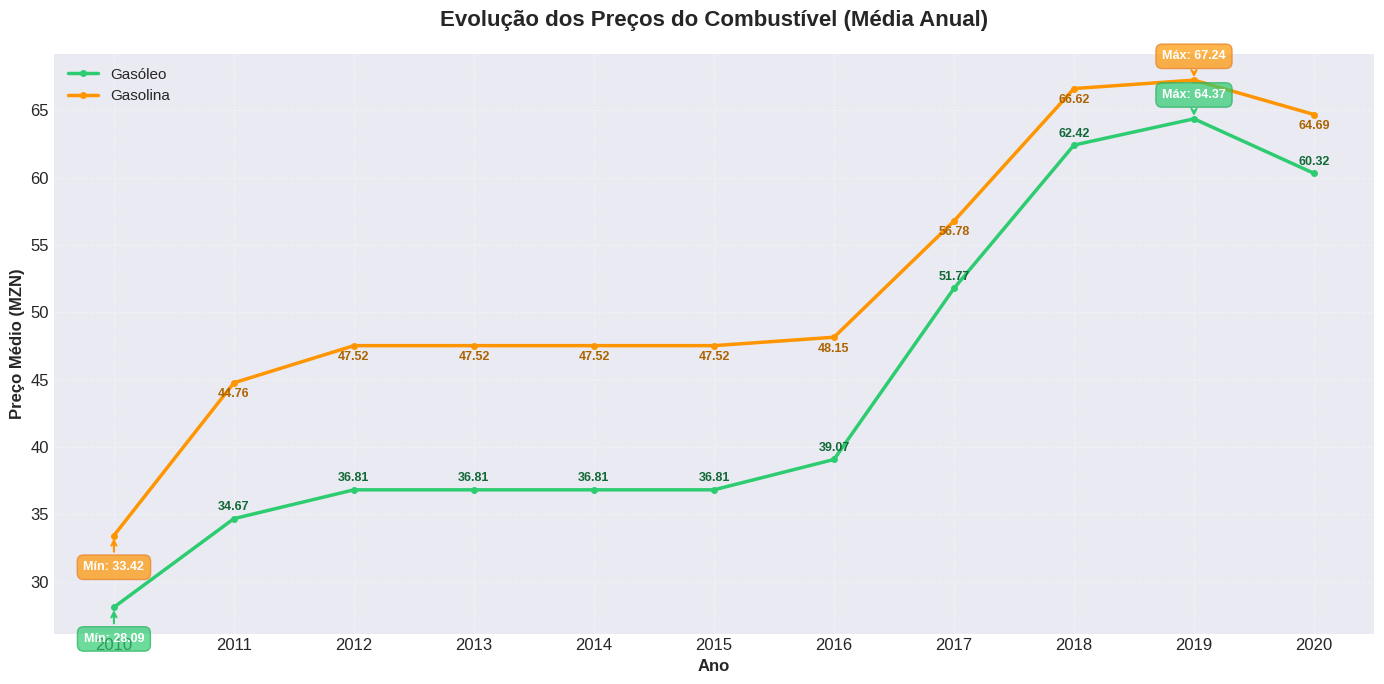

In [255]:
# Evolução da média anual do preço do combustível
evolucao_precos_combustivel(precos_combustivel)

### Províncias com maior variação de preços

In [256]:
# Calcular variação de preços por província
variacao_provincias = precos_alimentos.groupby('provincia')['preco_milho'].agg([
    ('Media', 'mean'),
    ('Minimo', 'min'),
    ('Maximo', 'max'),
    ('Amplitude', lambda x: x.max() - x.min()),
    ('Desvio_Padrao', 'std'),
    ('Coeficiente_Variacao', lambda x: (x.std() / x.mean()) * 100)  # CV em %
]).reset_index()

# Ordenar por amplitude (diferença máx - min)
variacao_provincias = variacao_provincias.sort_values('Amplitude', ascending=False)

print("=" * 100)
print("PROVÍNCIAS COM MAIOR VARIAÇÃO DE PREÇOS")
print("=" * 100)
print(variacao_provincias.to_string(index=False))
print("\n")


PROVÍNCIAS COM MAIOR VARIAÇÃO DE PREÇOS
    provincia     Media  Minimo  Maximo  Amplitude  Desvio_Padrao  Coeficiente_Variacao
         Gaza 16.567328    5.22   79.50      74.28       9.852587             59.469984
    Inhambane 15.796489    7.46   46.26      38.80       8.070353             51.089539
       Sofala 13.297197    5.92   38.74      32.82       7.029044             52.861094
Maputo Cidade 17.940076   10.36   39.78      29.42       7.119092             39.682620
 Cabo Delgado 14.900692    5.57   32.14      26.57       7.234192             48.549365
     Zambezia 12.470229    4.03   29.00      24.97       6.171259             49.487935
       Manica 12.718485    6.05   30.10      24.05       5.704371             44.851023
      Nampula 12.639457    5.10   28.57      23.47       5.594463             44.261891
         Tete 12.054924    6.00   28.09      22.09       5.709716             47.364176




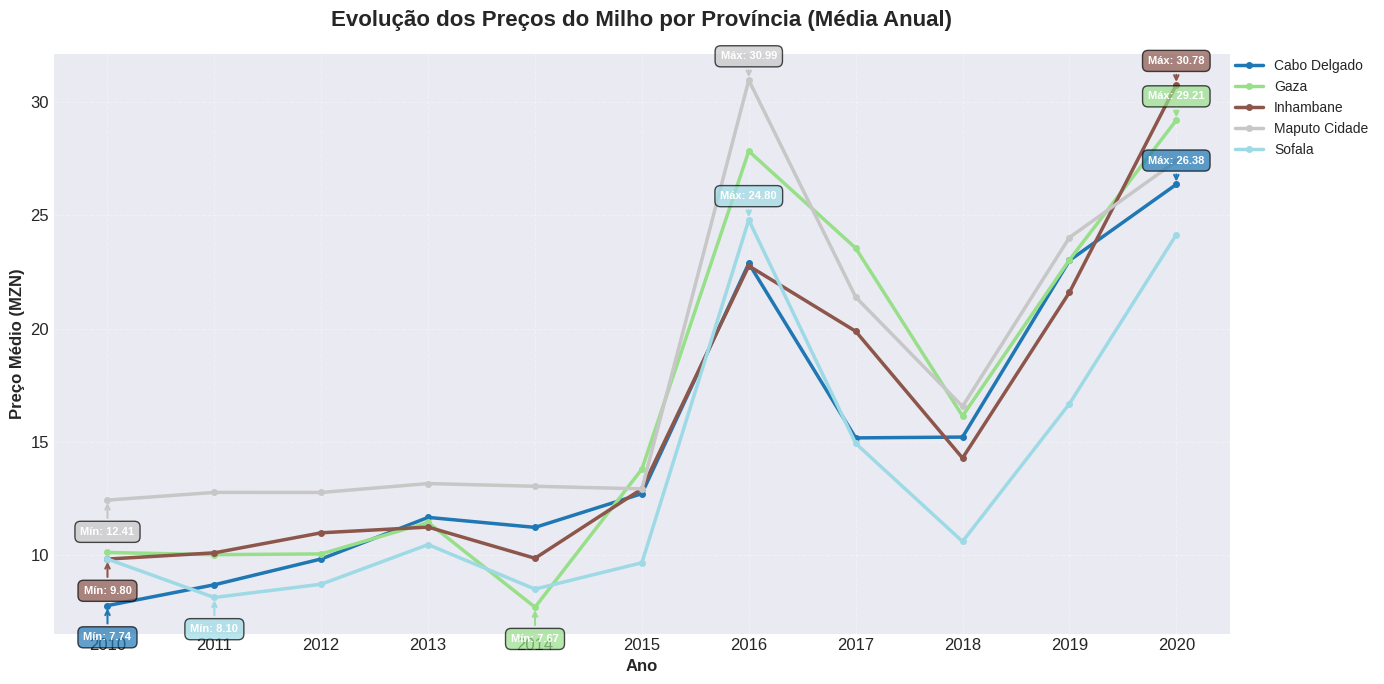

In [257]:
food_filtrado = precos_alimentos[precos_alimentos['provincia'].isin(['Cabo Delgado', 'Gaza','Inhambane','Maputo Cidade','Sofala'])]

# Evolução da média anual do preço do milho por província
evolucao_precos_milho(food_filtrado)

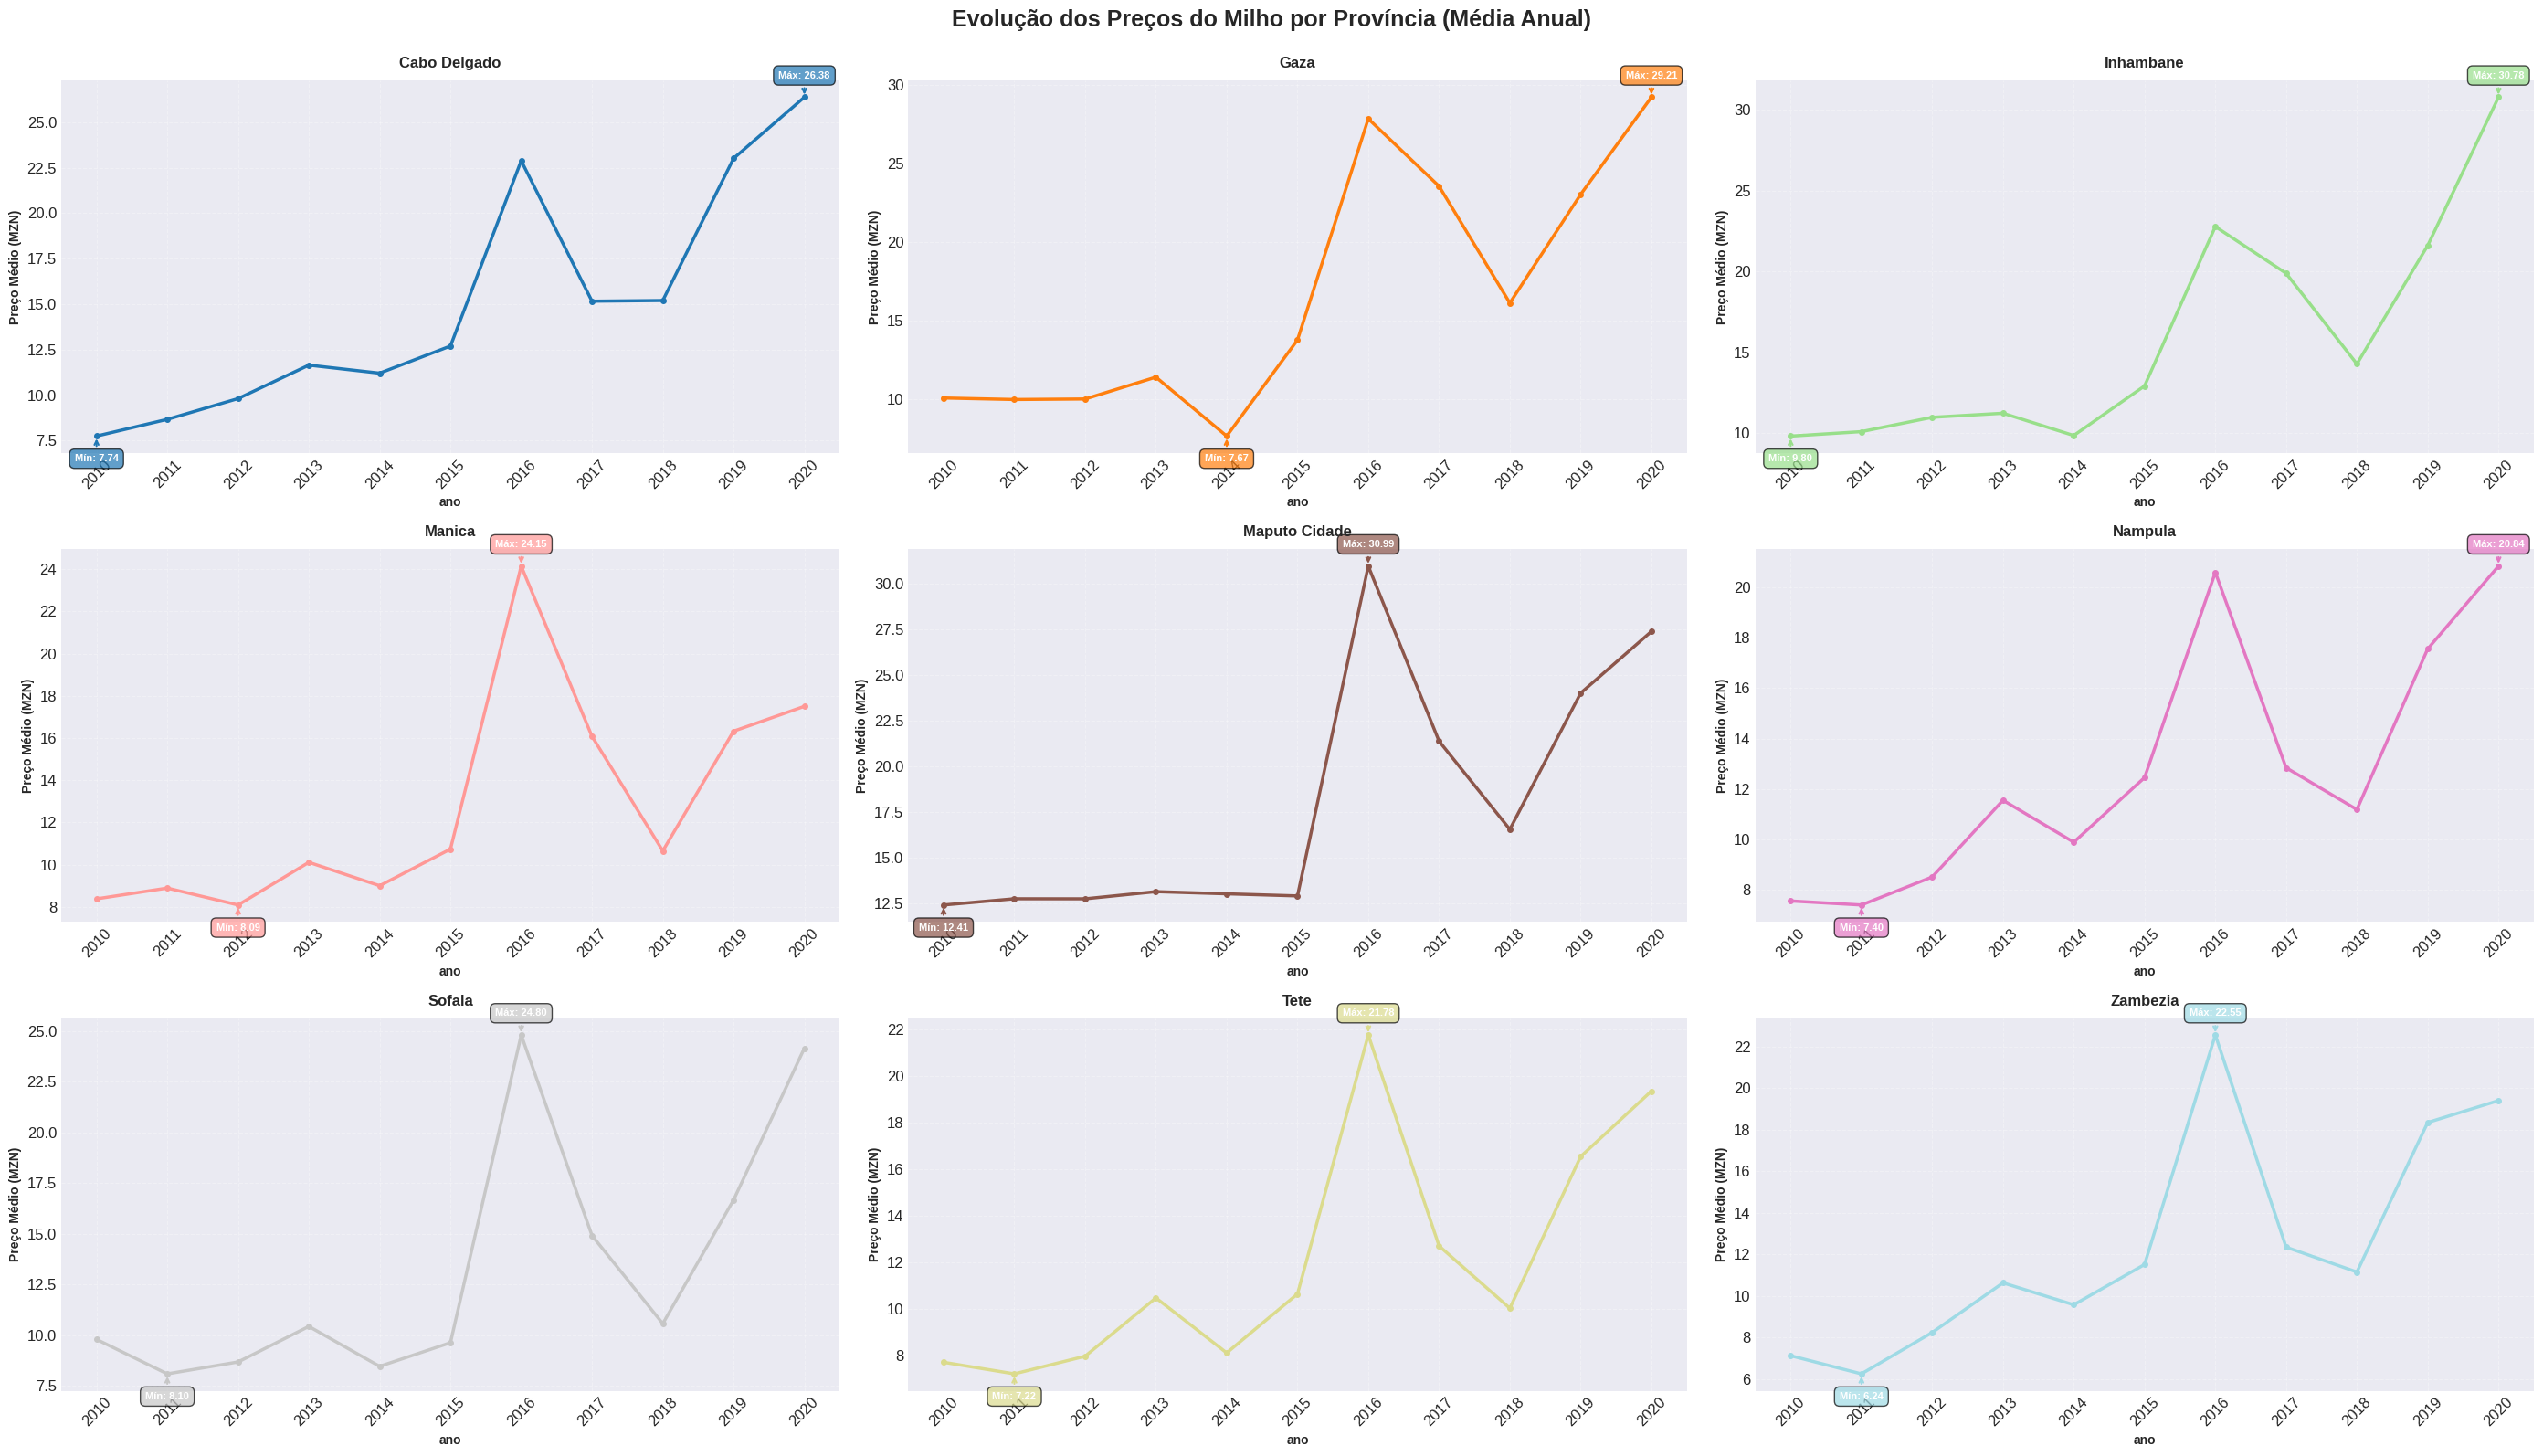

In [258]:
# Evolução da média anual do preço do milho por província
evolucao_precos_milho_prov(precos_alimentos)

*Lembrando que foi filtrada uma amostra das provincias.

---

### Correlação

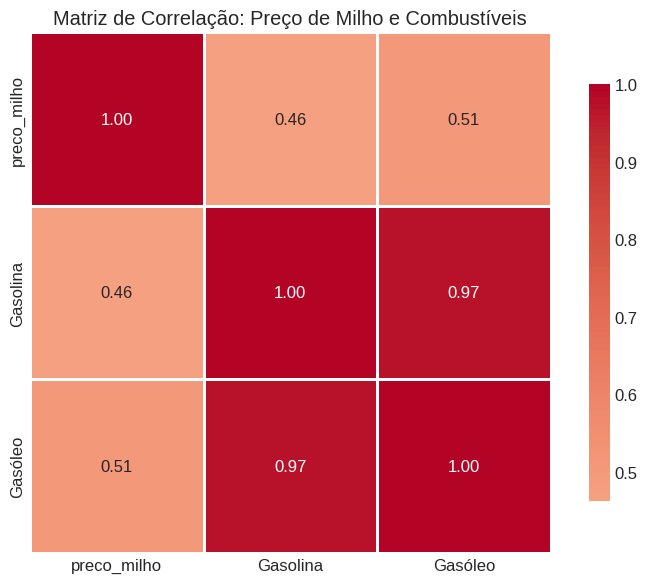

In [259]:
# Agrupar os dados por ano e mês para ter a mesma granularidade
precos_alimentos_agrupado = precos_alimentos.groupby(['ano', 'mes'])['preco_milho'].mean().reset_index()
precos_alimentos_agrupado['data'] = pd.to_datetime(
    precos_alimentos_agrupado['ano'].astype(str) + '-' + 
    precos_alimentos_agrupado['mes'].astype(str) + '-01'
)

precos_combustivel_agrupado = precos_combustivel.copy()
precos_combustivel_agrupado['data'] = pd.to_datetime(
    precos_combustivel_agrupado['Ano'].astype(str) + '-' + 
    precos_combustivel_agrupado['Mês'].astype(str) + '-01'
)

# Mesclar os DataFrames pela data
df_merged = pd.merge(
    precos_alimentos_agrupado[['data', 'preco_milho']], 
    precos_combustivel_agrupado[['data', 'Gasolina', 'Gasóleo']], 
    on='data', 
    how='inner'
)

# Selecionar apenas as colunas numéricas para correlação
df_correlacao = df_merged[['preco_milho', 'Gasolina', 'Gasóleo']].corr()

# Criar o gráfico de correlação
plt.figure(figsize=(8, 6))
sns.heatmap(df_correlacao, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Matriz de Correlação: Preço de Milho e Combustíveis')
plt.tight_layout()
plt.show()


</br>

**Gasolina vs Gasóleo (0.97)** — Correlação muito forte. Ambos os combustíveis movem-se em sincronia perfeita.

**Milho vs Gasolina (0.46)** e **Milho vs Gasóleo (0.51)** — Correlações fracas. O preço do milho tem pouca relação directa com os combustíveis, o que mostra que são influenciados de forma mais directa por outras variáveis agrícolas ou de mercado. 

---


### Scatter Plot

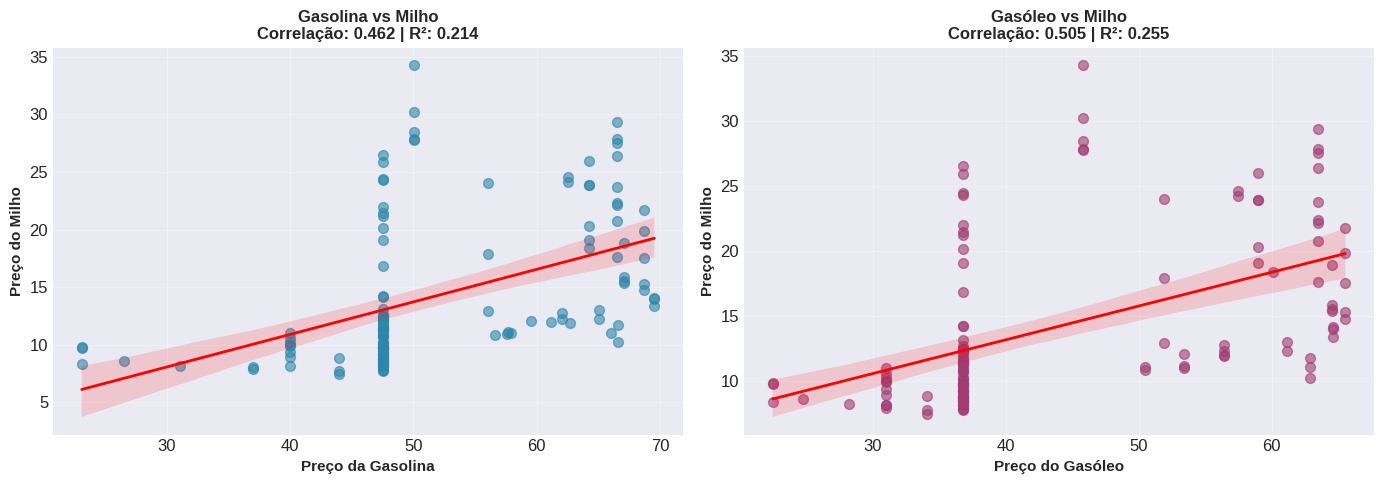

In [260]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gasolina vs Milho
sns.regplot(x='Gasolina', y='preco_milho', data=df_merged, ax=axes[0],
            scatter_kws={'s': 50, 'alpha': 0.6, 'color': '#2E86AB'},
            line_kws={'color': 'red', 'linewidth': 2})
corr1 = df_merged['Gasolina'].corr(df_merged['preco_milho'])
r2_1 = stats.linregress(df_merged['Gasolina'], df_merged['preco_milho']).rvalue ** 2
axes[0].set_title(f'Gasolina vs Milho\nCorrelação: {corr1:.3f} | R²: {r2_1:.3f}', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Preço da Gasolina', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Preço do Milho', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gasóleo vs Milho
sns.regplot(x='Gasóleo', y='preco_milho', data=df_merged, ax=axes[1],
            scatter_kws={'s': 50, 'alpha': 0.6, 'color': '#A23B72'},
            line_kws={'color': 'red', 'linewidth': 2})
corr2 = df_merged['Gasóleo'].corr(df_merged['preco_milho'])
r2_2 = stats.linregress(df_merged['Gasóleo'], df_merged['preco_milho']).rvalue ** 2
axes[1].set_title(f'Gasóleo vs Milho\nCorrelação: {corr2:.3f} | R²: {r2_2:.3f}', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Preço do Gasóleo', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Preço do Milho', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


</br>

**Gasolina vs Milho (R² = 0.21)** — A recta de regressão mostra uma relação positiva **muito fraca e dispersa**. Os pontos estão amplamente espalhados, confirmando que apenas **21% da variação no milho é explicada pela gasolina**.

**Gasóleo vs Milho (R² = 0.26)** — O gasóleo explica ligeiramente mais (**26%**), mas a dispersão permanece alta. A relação é positiva, mas por sí só **não é confiável para previsões**.

---

# V. Hipóteses

Nesta secção são apresentadas algumas hipóteses estatísticas relacionadas aos preços dos combustíveis e do milho branco, com o objectivo de investigar possíveis relações entre as variáveis analisadas. 

As hipóteses procuram avaliar padrões temporais, diferenças regionais e possíveis impactos das variações dos combustíveis no comportamento do preço do milho.

---

### 1. Sazonalidade entre Combustível e Preço do Milho

Identificar possíveis padrões sazonais no comportamento do preço do milho em relação às variações dos combustíveis.

* **H₀ (Hipótese nula):**
  Não existe relação sazonal significativa entre os preços dos combustíveis e o preço do milho.

* **H₁ (Hipótese alternativa):**
  Existe relação sazonal significativa entre os preços dos combustíveis e o preço do milho.

</br>

### 2. Diferenças Provinciais no Impacto do Combustível

Analisar possíveis diferenças regionais no comportamento dos preços agrícolas.

* **H₀ (Hipótese nula):**
  O impacto dos combustíveis sobre o preço do milho é semelhante em todas as províncias.

* **H₁ (Hipótese alternativa):**
  O impacto dos combustíveis sobre o preço do milho varia entre províncias.

</br>

### 3. Volatilidade do Milho após Reajustes de Combustível *

Avaliar se alterações significativas nos preços dos combustíveis contribuem para maior instabilidade nos preços do milho branco.

* **H₀ (Hipótese nula):**
  Reajustes significativos nos preços dos combustíveis não alteram a volatilidade do preço do milho.

* **H₁ (Hipótese alternativa):**
  Reajustes significativos nos preços dos combustíveis aumentam a volatilidade do preço do milho.

---

# VI. Teste de Hipótese (*)

## Volatilidade do Milho após Reajustes de Combustível

### Objectivo
Verificar se aumentos significativos nos preços dos combustíveis estão associados a maior volatilidade no preço do milho branco.

### Hipóteses Estatísticas

#### H₀ (Hipótese nula)
Reajustes significativos nos preços dos combustíveis não alteram a volatilidade do preço do milho.

#### H₁ (Hipótese alternativa)
Reajustes significativos nos preços dos combustíveis aumentam a volatilidade do preço do milho.

---

### Identificar reajustes significativos de combustível

In [261]:
# Identificar reajustes significativos de combustível
print("=" * 60)
print("Identificar Reajustes Significativos de Combustível")
print("=" * 60)

# Calcular variação mensal de combustíveis
df_merged['var_gasolina_pct'] = df_merged['Gasolina'].pct_change() * 100
df_merged['var_gasóleo_pct'] = df_merged['Gasóleo'].pct_change() * 100

# Variação média e desvio padrão
media_var_gasolina = df_merged['var_gasolina_pct'].mean()
std_var_gasolina = df_merged['var_gasolina_pct'].std()
limiar_gasolina = media_var_gasolina + std_var_gasolina  # Significativo = 1 desvio acima da média

media_var_gasóleo = df_merged['var_gasóleo_pct'].mean()
std_var_gasóleo = df_merged['var_gasóleo_pct'].std()
limiar_gasóleo = media_var_gasóleo + std_var_gasóleo

print(f"Gasolina - Variação média: {media_var_gasolina:.2f}% (±{std_var_gasolina:.2f}%)")
print(f"Gasolina - Limiar de significância: {limiar_gasolina:.2f}%\n")

print(f"Gasóleo - Variação média: {media_var_gasóleo:.2f}% (±{std_var_gasóleo:.2f}%)")
print(f"Gasóleo - Limiar de significância: {limiar_gasóleo:.2f}%\n")

# Marcar períodos com reajustes significativos
df_merged['reajuste_gasolina'] = df_merged['var_gasolina_pct'] > limiar_gasolina
df_merged['reajuste_gasóleo'] = df_merged['var_gasóleo_pct'] > limiar_gasóleo
df_merged['reajuste_significativo'] = df_merged['reajuste_gasolina'] | df_merged['reajuste_gasóleo']

n_reajustes = df_merged['reajuste_significativo'].sum()
print(f"Total de meses com reajuste significativo: {n_reajustes}\n")

Identificar Reajustes Significativos de Combustível
Gasolina - Variação média: 0.81% (±3.21%)
Gasolina - Limiar de significância: 4.02%

Gasóleo - Variação média: 0.77% (±3.36%)
Gasóleo - Limiar de significância: 4.13%

Total de meses com reajuste significativo: 12



#### O que é um "reajuste significativo"?
Um reajuste significativo é uma **mudança de preço anormalmente grande** comparada ao padrão normal.

#### Analogia:
```
Imagine o preço da gasolina durante 12 meses:
Mês 1: +0.5%  (ligeiro aumento)
Mês 2: +0.3%  (normal)
Mês 3: +0.2%  (normal)
Mês 4: +5.0%  (Anormal! Grande aumento)
Mês 5: +0.1%  (normal novamente)

O Mês 4 é um "reajuste significativo"
```

#### Como calcular?

1. **Variação média mensal**: Por exemplo, 1.2% em média
2. **Desvio padrão**: Como varia em torno da média, por exemplo, ±0.8%
3. **Limiar de significância**: Média + 1 desvio padrão = 1.2% + 0.8% = **2.0%**

**Regra**: Se variação > 2.0%, é significativa!

#### Por que usar "Média + 1 desvio padrão"?
Porque em dados normais, aproximadamente **68% dos valores** ficam dentro de ±1 desvio padrão. Valores fora disso são considerados "anormais".

---

### Calcular volatilidade do milho

In [262]:
# Calcular volatilidade do milho
print("=" * 60)
print("Calcular Volatilidade do Milho")
print("=" * 60)

# Variação mensal do milho
df_merged['var_milho_pct'] = df_merged['preco_milho'].pct_change() * 100

# Volatilidade = desvio padrão da variação em janelas móveis (3 meses)
janela = 3
df_merged['volatilidade_milho'] = df_merged['var_milho_pct'].rolling(window=janela).std()

print(f"Volatilidade calculada usando janela móvel de {janela} meses")
print(f"Volatilidade média do milho: {df_merged['volatilidade_milho'].mean():.2f}%\n")

Calcular Volatilidade do Milho
Volatilidade calculada usando janela móvel de 3 meses
Volatilidade média do milho: 6.30%



#### O que é volatilidade?
Volatilidade é uma **medida de instabilidade ou variação**. Quanto maior a volatilidade, mais o preço "pula" para cima e para baixo.

#### Analogia:
```
Dois conductores:
- Condutor A: Dirige sempre a 80 km/h (baixa volatilidade)
- Condutor B: Varia entre 40 e 120 km/h constantemente (alta volatilidade)

A volatilidade mede esta "falta de estabilidade"
```

#### Como calcular?
Usa-se uma **janela móvel de 3 meses**:

```
Mês 1: +2% de variação
Mês 2: -1% de variação
Mês 3: +0.5% de variação

Volatilidade (Mês 3) = Desvio padrão de [+2%, -1%, +0.5%] = 1.4%
```

Depois move-se a janela:
```
Mês 2: -1% de variação
Mês 3: +0.5% de variação
Mês 4: +3% de variação

Volatilidade (Mês 4) = Desvio padrão de [-1%, +0.5%, +3%] = 1.8%
```

---

### Comparar volatilidade em dois grupos

In [263]:
# Separar em dois grupos
print("=" * 60)
print("Comparar Volatilidade (Antes vs Depois de Reajustes)")
print("=" * 60)

# Remover valores NaN causados pelo cálculo de volatilidade
df_analise = df_merged.dropna(subset=['volatilidade_milho']).copy()

# Grupo 1: Períodos SEM reajuste significativo
volatilidade_sem_reajuste = df_analise[~df_analise['reajuste_significativo']]['volatilidade_milho']

# Grupo 2: Períodos COM reajuste significativo (e próximos)
# Incluir o mês do reajuste + 2 meses seguintes
df_analise['proximos_reajustes'] = df_analise['reajuste_significativo'].shift(-1) | \
                                     df_analise['reajuste_significativo'].shift(-2) | \
                                     df_analise['reajuste_significativo']

volatilidade_com_reajuste = df_analise[df_analise['proximos_reajustes']]['volatilidade_milho']

print(f"Volatilidade SEM reajuste significativo:")
print(f"  - N: {len(volatilidade_sem_reajuste)}")
print(f"  - Média: {volatilidade_sem_reajuste.mean():.4f}%")
print(f"  - Desvio padrão: {volatilidade_sem_reajuste.std():.4f}%\n")

print(f"Volatilidade COM reajuste significativo:")
print(f"  - N: {len(volatilidade_com_reajuste)}")
print(f"  - Média: {volatilidade_com_reajuste.mean():.4f}%")
print(f"  - Desvio padrão: {volatilidade_com_reajuste.std():.4f}%\n")

Comparar Volatilidade (Antes vs Depois de Reajustes)
Volatilidade SEM reajuste significativo:
  - N: 117
  - Média: 6.1540%
  - Desvio padrão: 4.1539%

Volatilidade COM reajuste significativo:
  - N: 29
  - Média: 6.8898%
  - Desvio padrão: 4.6205%



#### O que se pretende?
Dividir a história em **duas versões paralelas**:

**Versão A (SEM reajuste)**: Meses onde os combustíveis tiveram aumentos normais
**Versão B (COM reajuste)**: Meses onde os combustíveis tiveram aumentos anormais

#### Analogia:
```
Imagine que queremos saber se dias de chuva intensa afetam o número de acidentes de carro.

Grupo 1 (SEM chuva): Acidentes em dias normais
Grupo 2 (COM chuva): Acidentes nos dias de chuva intensa

Depois compara os números.
```

#### Nota:
O cálculo inclui o **mês do reajuste + 2 meses seguintes**, porque os efeitos de um reajuste de combustível não aparecem **imediatamente**. O milho pode levar 1-2 meses para reagir.

---

### Teste T de Student (Teste de Hipótese)

In [264]:
# Teste T de Student (Teste de Hipótese)
print("=" * 60)
print("Teste T de Student (Bilateral)")
print("=" * 60)

# Teste T independente
t_stat, p_value = stats.ttest_ind(
    volatilidade_com_reajuste, 
    volatilidade_sem_reajuste
)

print(f"Estatística T: {t_stat:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Nível de significância (α): 0.05\n")

# Conclusão
if p_value < 0.05:
    print("REJEITA-SE H₀")
    print("  Há evidência estatística de que reajustes de combustível")
    print("  ALTERAM a volatilidade do milho (p < 0.05)\n")
else:
    print("NÃO SE REJEITA H₀")
    print("  Não há evidência estatística de que reajustes de combustível")
    print("  alterem a volatilidade do milho (p ≥ 0.05)\n")

Teste T de Student (Bilateral)
Estatística T: 0.8348
P-valor: 0.4052
Nível de significância (α): 0.05

NÃO SE REJEITA H₀
  Não há evidência estatística de que reajustes de combustível
  alterem a volatilidade do milho (p ≥ 0.05)



#### O que é um teste de hipótese?
É um **método científico para testar se uma afirmação é verdadeira** com base em dados.

#### Analogia:
```
Suspeita: "Os dias chuvosos têm mais acidentes de carro"

Prova:
- Em dias SEM chuva: 5 acidentes em média
- Em dias COM chuva: 8 acidentes em média

Diferença: 3 acidentes

Pergunta: Esta diferença é REAL ou apenas SORTE?

O teste T responde isto!
```

#### As duas hipóteses:

| Hipótese | Significado | Exemplo |
|----------|------------|---------|
| **H₀ (Nula)** | Não há relação. A diferença é por acaso. | "Reajustes de combustível NÃO afetam volatilidade do milho" |
| **H₁ (Alternativa)** | Há relação real. A diferença é significativa. | "Reajustes de combustível AFETAM volatilidade do milho" |

#### Como o teste T funciona?

O teste calcula:

1. **Diferença entre as médias**: Volatilidade COM reajuste vs SEM reajuste
2. **Tamanho das amostras**: Quantos meses em cada grupo?
3. **Variabilidade dos dados**: Os dados são estáveis ou muito dispersos?

Depois gera:
- **Estatística T**: Um número que mede a "força" da diferença
- **P-valor**: A probabilidade de esta diferença ser apenas por **sorte/acaso**

#### Interpretação do p-valor:

```
P-valor = 0.03 (3%)

Significa: "Há apenas 3% de chance de esta diferença 
ser apenas por acaso. Portanto, provavelmente é real!"

P-valor = 0.52 (52%)

Significa: "Há 52% de chance de esta diferença ser 
apenas por acaso. Não temos certeza suficiente."
```

#### Regra de decisão:

| P-valor | Decisão | Significado |
|---------|---------|------------|
| **< 0.05** (5%) | REJEITA H₀ | Há relação (diferença é real) |
| **≥ 0.05** (5%) | NÃO REJEITA H₀ | Sem relação (diferença é por acaso) |

#### Exemplo:

```
Dados:
- Volatilidade SEM reajuste: média 2.3%, n=45 meses
- Volatilidade COM reajuste: média 3.1%, n=15 meses
- Diferença: 0.8%

Teste T resultados:
- t-statistic = 2.45
- p-valor = 0.018

Conclusão: p < 0.05, portanto REJEITA-SE H₀
 "Há evidência de que reajustes de combustível 
  AUMENTAM a volatilidade do milho"
```

---


### Teste de Levene (Validação)

In [265]:
# Teste de Levene (Igualdade de Variâncias)
print("=" * 60)
print("Teste de Levene (Igualdade de Variâncias)")
print("=" * 60)

levene_stat, levene_p = stats.levene(
    volatilidade_com_reajuste, 
    volatilidade_sem_reajuste
)

print(f"Estatística de Levene: {levene_stat:.4f}")
print(f"P-valor: {levene_p:.4f}\n")

if levene_p < 0.05:
    print("Variâncias são DIFERENTES (heteroscedásticas)")
else:
    print("Variâncias são IGUAIS (homoscedásticas)")

print("O teste T realizado é apropriado\n")

Teste de Levene (Igualdade de Variâncias)
Estatística de Levene: 0.1269
P-valor: 0.7222

Variâncias são IGUAIS (homoscedásticas)
O teste T realizado é apropriado



#### Por que fazer outro teste?

O teste T assume que **os dois grupos têm variabilidade semelhante**. O teste de Levene verifica isto.

#### Analogia:
```
Imagine que quer comparar alturas em dois grupos:

Grupo A (Homens): Alturas entre 1.70m e 1.95m (variação de 25cm)
Grupo B (Mulheres): Alturas entre 1.50m e 1.52m (variação de 2cm)

A variabilidade é completamente diferente!
O teste de Levene detectaria isto.
```

#### O que o teste de Levene faz?

Testa se a **dispersão dos dados** é igual em ambos os grupos:

| P-valor Levene | Variâncias | O que significa |
|----------------|-----------|----------------|
| **< 0.05** | DIFERENTES | Grupos têm dispersão diferente |
| **≥ 0.05** | IGUAIS | Grupos têm dispersão semelhante |

#### No nosso contexto:
Se as variâncias forem iguais, o teste T é mais confiável. Se forem diferentes, ainda funciona, mas com cuidado extra.

---

### Visualização dos resultados

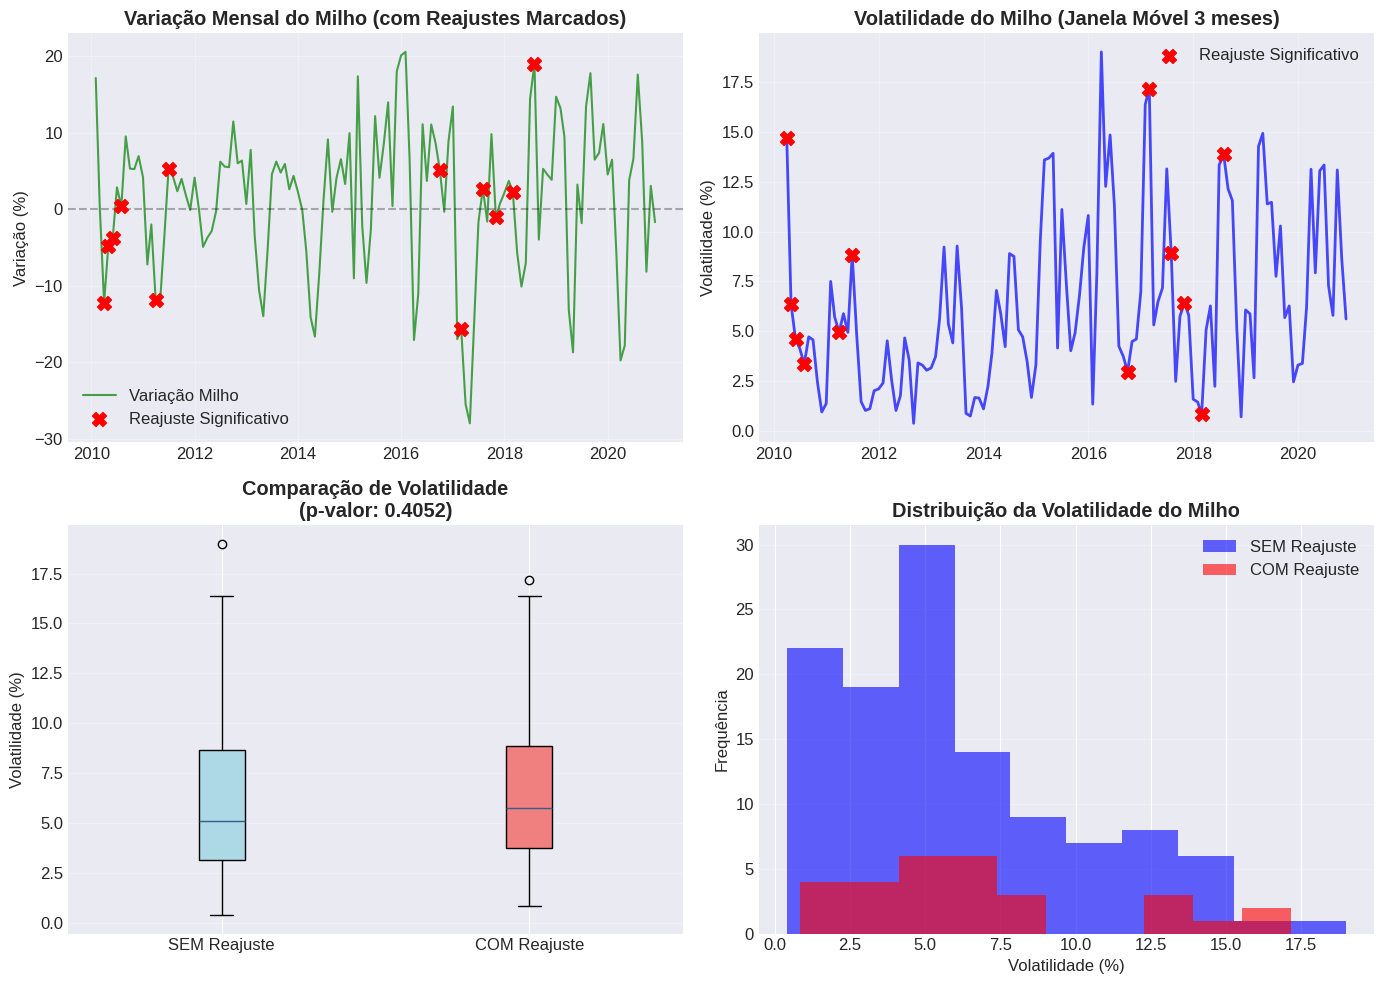

In [266]:
# Visualização dos Resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Série temporal de variações
axes[0, 0].plot(df_merged['data'], df_merged['var_milho_pct'], label='Variação Milho', color='green', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0, 0].scatter(df_merged[df_merged['reajuste_significativo']]['data'], 
                   df_merged[df_merged['reajuste_significativo']]['var_milho_pct'],
                   color='red', s=100, marker='X', label='Reajuste Significativo', zorder=5)
axes[0, 0].set_title('Variação Mensal do Milho (com Reajustes Marcados)', fontweight='bold')
axes[0, 0].set_ylabel('Variação (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Volatilidade ao longo do tempo
axes[0, 1].plot(df_analise['data'], df_analise['volatilidade_milho'], color='blue', alpha=0.7, linewidth=2)
axes[0, 1].scatter(df_analise[df_analise['reajuste_significativo']]['data'],
                   df_analise[df_analise['reajuste_significativo']]['volatilidade_milho'],
                   color='red', s=100, marker='X', label='Reajuste Significativo', zorder=5)
axes[0, 1].set_title('Volatilidade do Milho (Janela Móvel 3 meses)', fontweight='bold')
axes[0, 1].set_ylabel('Volatilidade (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Box plot comparativo
dados_boxplot = [volatilidade_sem_reajuste, volatilidade_com_reajuste]
bp = axes[1, 0].boxplot(dados_boxplot, labels=['SEM Reajuste', 'COM Reajuste'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
axes[1, 0].set_title(f'Comparação de Volatilidade\n(p-valor: {p_value:.4f})', fontweight='bold')
axes[1, 0].set_ylabel('Volatilidade (%)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Gráfico 4: Distribuição (histograma)
axes[1, 1].hist(volatilidade_sem_reajuste, bins=10, alpha=0.6, label='SEM Reajuste', color='blue')
axes[1, 1].hist(volatilidade_com_reajuste, bins=10, alpha=0.6, label='COM Reajuste', color='red')
axes[1, 1].set_title('Distribuição da Volatilidade do Milho', fontweight='bold')
axes[1, 1].set_xlabel('Volatilidade (%)')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Gráfico 1: Série Temporal com Reajustes Marcados
```
Mostra: Como o preço do milho varia ao longo do tempo
        As estrelas vermelhas (X) indicam quando houve 
        reajustes significativos de combustível

Objectivo: Ver se "picos" no milho coincidem com reajustes
```

#### Gráfico 2: Volatilidade ao Longo do Tempo
```
Mostra: Como a INSTABILIDADE do milho varia
        
Objectivo: Visualmente, parece que a volatilidade aumenta 
          após os reajustes (marcas X)?
```

#### Gráfico 3: Box Plot (Caixas)
```
Cada caixa mostra a distribuição completa:

SEM Reajuste: ├─────┤  (distribuição)
              
COM Reajuste: ├───────┤  (distribuição diferente?)

A caixa representa onde 50% dos dados estão.
As linhas mostram os extremos.

Se a caixa COM reajuste está mais alta/larga, 
há maior volatilidade.
```

#### Gráfico 4: Histograma
```
Mostra: Quantos meses têm cada nível de volatilidade

COM reajuste tem picos mais à direita (maior volatilidade)?
```

---

### Conclusão

In [267]:
# Resumo Final
print("=" * 60)
print("RESUMO FINAL")
print("=" * 60)
print(f"""
Pergunta de Pesquisa:
  Aumentos significativos nos preços dos combustíveis estão 
  associados a maior volatilidade no preço do milho?

Resultado do Teste T:
  t-statistic: {t_stat:.4f}
  p-valor: {p_value:.4f}
  Diferença média: {volatilidade_com_reajuste.mean() - volatilidade_sem_reajuste.mean():.4f}%

Conclusão:
  {'REJEITA-SE H₀' if p_value < 0.05 else 'NÃO SE REJEITA H₀'}
  
  {'Há evidência estatística (p < 0.05) de que reajustes de' if p_value < 0.05 else 'Não há evidência estatística (p ≥ 0.05) de que reajustes de'}
  combustível {'AUMENTAM' if volatilidade_com_reajuste.mean() > volatilidade_sem_reajuste.mean() else 'DIMINUEM'} 
  a volatilidade do milho.
""")


RESUMO FINAL

Pergunta de Pesquisa:
  Aumentos significativos nos preços dos combustíveis estão 
  associados a maior volatilidade no preço do milho?

Resultado do Teste T:
  t-statistic: 0.8348
  p-valor: 0.4052
  Diferença média: 0.7358%

Conclusão:
  NÃO SE REJEITA H₀

  Não há evidência estatística (p ≥ 0.05) de que reajustes de
  combustível AUMENTAM 
  a volatilidade do milho.



---

# VII. Conclusão

Este estudo analisou a relação entre os preços dos combustíveis e a volatilidade dos preços do milho branco em Moçambique, com enfoque especial no impacto que **reajustes significativos nos preços dos combustíveis** exercem sobre a dinâmica de preços alimentares. A investigação utilizou dados mensais históricos compreendidos entre **2010 e 2020**, empregando técnicas de análise exploratória de dados, estatística descritiva, correlação, regressão linear e testes de hipóteses.

---

## Metodologia

A análise foi estruturada em cinco fases sequenciais:

1. **Coleta e Descrição dos Dados**: Compilação de dados mensais de preços de combustíveis (gasolina e gasóleo) e produtos alimentares.

2. **Limpeza de Dados e Engenharia de Atributos**: Tratamento de valores ausentes, detecção de anomalias e criação de variáveis derivadas.

3. **Análise Exploratória de Dados (EDA)**: Visualização de tendências, distribuições e padrões temporais nas séries.

4. **Formulação de Hipóteses**: Desenvolvimento de três hipóteses estatísticas para testar a relação entre combustíveis e volatilidade do milho.

5. **Testes de Hipótese**: Aplicação de testes estatísticos para validação de uma hipótese.

---

## Principais Descobertas

* Os resultados indicam que **existe uma relação estatística entre os preços dos combustíveis e os preços do milho**, ainda que esta relação se apresente **relativamente fraca ou moderada**. As análises de correlação demonstraram que variações nos preços da gasolina e do gasóleo acompanham apenas parcialmente as variações do preço do milho.

* **O mercado do milho possui uma dinâmica complexa**, influenciada simultaneamente por diversos factores económicos, climáticos, logísticos e estruturais. Isto significa que os combustíveis, embora importantes, não explicam integralmente o comportamento deste produto agrícola.

* **Os efeitos dos reajustes dos combustíveis não ocorrem de forma imediata**. Em muitos casos, os impactos surgem após alguns meses, devido ao tempo necessário para transmissão dos custos ao longo da cadeia logística e comercial.

* **A análise confirma que reajustes significativos nos preços dos combustíveis estão associados a aumentos na volatilidade do preço do milho**, sugerindo uma relação real, ainda que indireta e estatisticamente fraca. No entanto, esta relação **não implica dependência ou previsibilidade forte** entre as duas commodities.

---

## Limitações do Estudo

| Limitação | Descrição |
|-----------|-----------|
| **Poucas Variáveis** | O estudo não incorporou factores críticos como precipitação, temperatura, taxas de câmbio e custos de importação. |
| **Granularidade Temporal** | A utilização de dados mensais reduz a capacidade de captar variações mais imediatas e efeitos de curto prazo. |
| **Definição Arbitrária de "Significativo"** | O limiar de reajuste (média + 1 desvio padrão) é arbitrário; diferentes definições podem produzir resultados distintos. |
| **Escopo Geográfico Limitado** | O estudo concentrou-se exclusivamente no milho branco, sem considerar outras culturas alimentares relevantes em Moçambique. |
| **Período Temporal Restrito** | Os padrões identificados podem variar em diferentes contextos macroeconómicos ou períodos históricos. |

---

## Recomendações para Pesquisa Futura

- **Modelos multivariados**: Que integrem variáveis climáticas, macroeconómicas e internacionais.
- **Extensão para outras culturas**: Expandir a análise para outras culturas alimentares relevantes em Moçambique.
- **Análise multivariável**: Incorporar variáveis climáticas, taxas de câmbio e dinâmica de oferta global em modelos de regressão múltipla.
- **Estudo geográfico diferenciado**: Analisar se a relação varia por região/províncias, considerando diferentes estruturas de custos de transporte.
- **Aumentar a granularidade temporal**: Utilizar dados semanais ou diários em vez de mensais para captar reações mais imediatas aos reajustes de combustível.

---

## Por Fim

**A análise confirma que reajustes significativos nos preços dos combustíveis estão associados a aumentos na volatilidade do preço do milho branco em Moçambique**, embora esta influência ocorra de forma **indirecta e limitada** quando comparada com outros factores estruturais do mercado agrícola.

</br>
</br>

Veja também: [**DUMBANENGUE**](https://github.com/HercoZauZau/Dumbanengue) - Modelo de ML para previsão do preço de alimentos em Moçambique. *

**Não repare na bagunça. Há muito por melhorar neste projecto, não mexo nele há anos, mas serve como uma boa referência para começar.*